
# Семантический поиск по документам на старославянском из НКРЯ

В этой работе вы будете реализовывать поиск по документам на старославянском языке.  

Корпус: фрагменты из старославянского подкорпуса НКРЯ.

## Задания
Каждое домашнее задание включает 2 темы лекций. Например, это задание направлено на освоение PyTorch и работу с эмбеддингами. Обратите внимание на **вопросы и эксперименты**. Чтобы получать максимальный балл за задания, необходимо писать свои рассуждения и анализировать результы экспериментов. В таком случае оценивается не правильность ответа, а сам анализ и ход рассуждений (даже если они ошибочны). Так как задания достаточно объемные, то на их выполнение будет даваться примерно 1,5 недели. Все задания довольно beginner-friendly: в комментариях указано, что необходимо сделать.

## Как сдавать?
Готовый файл формата ipynb необходимо отправить через [форму](https://forms.gle/VXYNM6GZCbbNP22h6). Не забудьте указать фамилию в названии файла

Некоторые задания надо будет сдавать в виде ссылки на репозиторий (например, финальный проект).

Нельзя скидывать ссылку на Colab, задание в такой форме не будет принято

Если вы скидываете ссылку на GitHub, то задание будет оцениваться с учетом того, когда были внесены в него последние изменения. То есть если правки внесены после дедлайна, то отнимаются штрафные баллы.

##Оценка
Чтобы получить 7 баллов, вам достаточно сделать основную часть заданий (где вам нужно вставить части кода). Чтобы получить больше, нужно выполнить часть заданий, где весь код вы пишите самостоятельно. Эти задания примерно такой же сложности, но нужно проявить чуть больше фантазии.

Лучше сдавать задание до дедлайна, но если не вышло, то у вас есть ровно неделя после дедлайна, чтобы его сдать. Каждый день от максимального балла отнимается -1 штрафной. Если вы сдали задание через 2 дня и получили 10, то в итоге будет только 8. В последний день вы максимум можете получить 3 балла, даже если сделаете все на 10.

## Challenge
В каждом домашнем задании будет **challenge**, в котором будет предложено более глубоко погрузиться в задачу. Во-первых, это задания с повышенной сложностью: они включают работу с разными библиотеками (как в этом дз), обучение моделей, больше экспериментов. Во-вторых, за выполнение этих заданий будут отдельные бонусы. Возможные бонусы:

1.   Минимальный штраф за опоздание в течение недели: -1 балл в первую половину недели (первые 3,5 дня), -2 балла во вторую половину.
2.   Если вы выполняете все задания из категории Challenge, тогда за финальный проект вы получаете 3 дополнительных балла к вашей оценке.
3. Если вы выполняете 3 задания из этой категории, тогда вы получаете дополнительно 6 баллов, которые вы можете добавить к вашим дз (вы сами выбираете, к каким именно). В таком случае требование - выполнить дз минимум на 5 баллов.





## Часть 1. Предобработка текста и запроса (1 балл)

1 балл - если все сделано верно, придуманы запросы, есть ответ на вопрос про исторические

0.5 балла - 1-2 ошибки, нет ответа на вопрос

0 баллов - больше 2 ошибок

Сначала сделаем **простую предобработку** текстов и запросов:
- приведём текст к нижнему регистру;
- уберём лишние пробелы;
- уберём дубликаты;
- уберём лишние обозначения.

Подумайте, стоит ли заменять или очищать буквы, которые не используются. Если стоит, то проделайте это с текстами. Напишите свой комментарий об этом ниже.


**Удалим устаревшие символы(основные, которые легко поддаются правилам). Так как они только вносят шум, ни одна общая модель на них не обучалась**

In [210]:
import gdown

url = 'https://drive.google.com/file/d/10YFHrJJJFjJV7jolqz7Iio-90eMiINJ-/view?usp=sharing'

gdown.download(url, output='test', quiet=False, fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=10YFHrJJJFjJV7jolqz7Iio-90eMiINJ-
To: /content/test
100%|██████████| 76.5k/76.5k [00:00<00:00, 23.7MB/s]


'test'

In [211]:
import json

file_path = '/content/test'

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

unique_chars = set()

for word, examples in data.items():
    for char in word:
        unique_chars.add(char)
    if isinstance(examples, list):
        for text in examples:
            for char in text:
                unique_chars.add(char)


print(f"Всего уникальных символов: {len(unique_chars)}\n")
print("Уникальные символы:")
print(''.join(unique_chars))


Всего уникальных символов: 86

Уникальные символы:
НсЧФиЛуУьiд–[}ш4н]_sЗcщме»ч1оКЦАпИт«афПВ„9,ѳТъХрСюкМях8О“РБДЕы{6взй—.;гбл-ц30:і725ѣГ ж


In [209]:
def normalize_historical_orthography(text: str) -> str:
    replacements = {
        'ѣ': 'е',      # ять → е
        'ѳ': 'ф',      # фита → ф
        'і': 'и',      # и десятеричное → и
    }

    result = text
    for old, new in replacements.items():
        result = result.replace(old, new)

    # Убираем твёрдый знак в конце слов
    result = re.sub(r'ъ\b', '', result)

    return result

In [212]:
import re
def normalize_texts(text: str) -> str:
    if not isinstance(text, str):
        return text
    text = text.lower()
    text = normalize_historical_orthography(text)
    text = re.sub(r'\{\s*л\._.*?\}', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

all_texts = []
word_text_pairs = []

for word, excerpts in data.items():
    unique_excerpts = []
    seen_excerpts = set()

    for excerpt in excerpts:
        normalized_excerpt = normalize_texts(excerpt)

        if normalized_excerpt and normalized_excerpt not in seen_excerpts:
            unique_excerpts.append(excerpt)
            seen_excerpts.add(normalized_excerpt)

    for excerpt in unique_excerpts:
        all_texts.append(excerpt)
        word_text_pairs.append((word, excerpt))

normalized_texts = [normalize_texts(text) for text in all_texts]


Вам необходимо визуализировать эмбеддинги слов из этих документов с помощью PCA и придумать 8 запросов на современном русском языке и 3 запроса на старославянском. PCA поможет вам увидеть, какие темы преобладают в корпусе, будет проще сориентироваться.


In [213]:
normalized_texts

['и народ самой трезвой, никакова человека нигде отнюдь никогда пьянаго не увидишь; а питей всяких, вин виноградных розных множество изрядных, также разолинов и водак анисовых изрядных, из винограднаго вина сиженых, много, толко мало их употребляют, а болше употребляют в питьях лимонадов, симады, кафы, чекулаты и иных, тому ж подобных, с которых человеку пьяну быть невозможно.',
 'при тех домех поделаны лавки изрядные, в которых продают сахары узорочные и иные всякие канфекты и напитки всякие: чекулаты, кафы, лимонады и иные всякие, тому подобные; и табак, дымовой и носовой, всякой; а в ыных лавках тут продают и тавары всякие.',
 'и как я с того карабля сошел, и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью, а в том листе пишет сице:',
 'в том времени ветер переменил дыхание, однако ж был между востоку и полудня, которым карабль наш в 5 часов убежал 25 миль италиянских.',
 'а служба ево суть такая: имеет тот капитан свой караб

In [10]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.2 MB/s eta 0:00:00


In [14]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 30.7 MB/s eta 0:00:00


In [15]:
def tokenize_text(text: str) -> list:
    return [token for token in text.split() if len(token) > 2]

tokenized_sentences = [tokenize_text(text) for text in all_texts]
tokenized_sentences = [sent for sent in tokenized_sentences if sent]

In [214]:
from gensim.models import FastText

#Для векторизации используйте FastText. Параметры можете изменить так, чтобы было нагляднее на визуализации
# vector_size: размерность вектора (для маленьких данных лучше брать 20-50)
# window: окно контекста
# min_count: игнорировать слова, которые встречаются реже N раз
#сначала токенизируйте уже очищенные тексты
model = FastText(tokenized_sentences, vector_size=40, window=3, min_count=3, sg=1)

# Доступ к векторам осуществляется через интерфейс .wv (Word Vectors)
print("Вектор слова:", model.wv['слово'])

Вектор слова: [-1.1901042e-03  1.8394719e-03 -6.6194392e-05  9.7420224e-04
  3.4163429e-03  9.4148731e-05 -8.1907201e-04 -5.7768170e-04
 -1.6849267e-03 -4.1366601e-03  4.9088807e-03  1.1781255e-03
  3.1208482e-03 -3.8410055e-03  1.2526485e-03  6.0728111e-04
  9.0404891e-04  1.0202036e-02 -2.8374106e-05  7.0930074e-04
  8.6956294e-03 -7.7234535e-03  3.4787427e-04 -1.9150550e-03
 -5.1477924e-03  2.7271870e-05 -4.0056906e-03  1.2541545e-03
  4.7395080e-03  3.3104122e-03  2.5930840e-03 -2.0999061e-03
 -2.0540834e-03  1.7499331e-03  3.4948743e-03  2.7344383e-03
  5.0741592e-03 -3.2842818e-03  5.4808739e-03 -3.3895078e-03]


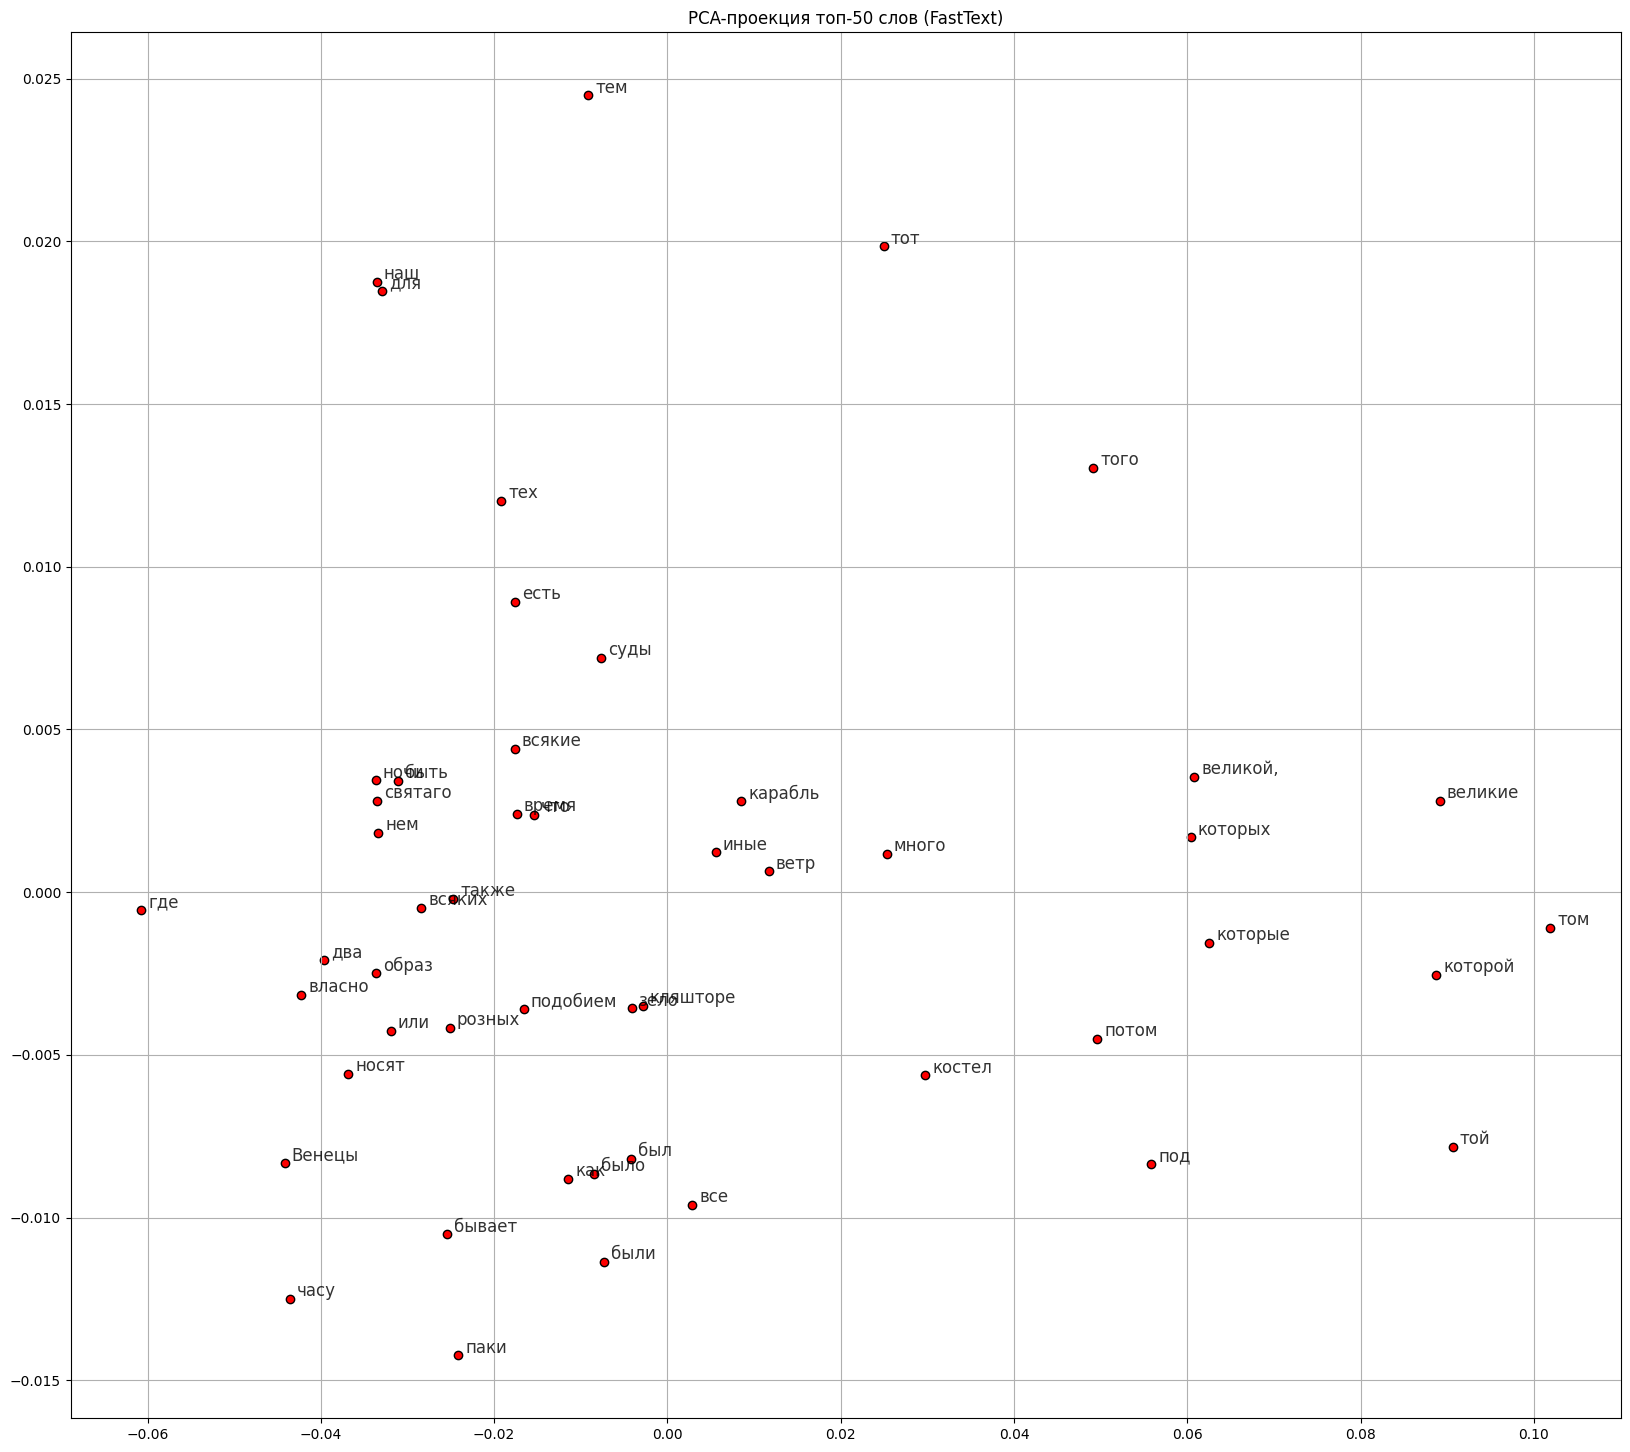

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings_pca(model, top_n=100):
    """
    Визуализирует top_n самых частотных слов из модели.
    """
    # Извлекаем слова и их векторы
    words = list(model.wv.index_to_key)[:top_n] # Берем только первые N слов
    vectors = np.array([model.wv[word] for word in words])

    # Инициализируем PCA
    pca = PCA(n_components=2)

    # ОБУЧЕНИЕ PCA: преобразуем векторы в координаты (x, y)
    coords = pca.fit_transform(vectors)

    # ВИЗУАЛИЗАЦИЯ (чуток поменяла figsizw)
    plt.figure(figsize=(20, 18))
    plt.scatter(coords[:, 0], coords[:, 1], c='red', edgecolors='k')

    for i, word in enumerate(words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]),
                     fontsize=12, alpha=0.8, xytext=(5, 2),
                     textcoords='offset points')

    plt.title(f"PCA-проекция топ-{top_n} слов (FastText)")
    plt.grid(True)
    plt.show()

# Запуск функции
plot_embeddings_pca(model, top_n=50)

In [18]:
# Пример запроса
queries = [
    {
        "query_id": 0,
        "text": "поездка на корабле из порта",
        "relevant_docs": [0, 1]
    },
]


In [217]:
queries = [
    #  8 запросов на русском языке
    {
        "query_id": 0,
        "text": "капитан Иван Лазоревич",
        "relevant_docs": [2,4,5,9,56]
    },
    {
        "query_id": 1,
        "text": "выход корабля из порта",
        "relevant_docs": [7]
    },
    {
        "query_id": 2,
        "text": "дворянин московский бесстрашный",
        "relevant_docs": [5, 50, 53]
    },

    {
        "query_id": 3,
        "text": "святая позолоченная икона",
        "relevant_docs": [42, 52]
    },
    {
        "query_id": 4,
        "text": "погребец или бутылка с вином",
        "relevant_docs": [120, 122, 130]
    },
    {
        "query_id": 5,
        "text": "золотой или серебряный дукат",
        "relevant_docs": [4, 7, 114]
    },
    {
        "query_id": 6,
        "text": "круг на полу",
        "relevant_docs": [115]
    },
    {
        "query_id": 7,
        "text": "иностранцы турки и греки",
        "relevant_docs": [4, 8, 10, 11, 31, 152]
    },

    # 3 запроса на старославянском

    {
        "query_id": 8,
        "text": "круживами золотными расшито",
        "relevant_docs": [93, 95]
    },
    {
        "query_id": 9,
        "text": "мужска и женска полу",
        "relevant_docs": [63, 93]
    },

    {
        "query_id": 10,
        "text": "вѣсу гривенок",
        "relevant_docs": [123]
    },
]


## Часть 2. Baseline: лексический поиск через TF-IDF (1 балл)

Сначала построим простой baseline:
- векторизуем документы через TF-IDF,
- векторизуем запросы,
- ищем наиболее похожие документы.


1 балл - все сделано верно, допускается до 3 ошибок или неточностей

0.5 - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно






In [218]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer()

#Постройте словарь на документах и векторизуйте их
doc_matrix_tfidf = tfidf.fit_transform(normalized_texts)
#Векторизуйте запросы
query_texts = [normalize_texts(q["text"]) for q in queries]
query_matrix_tfidf = tfidf.transform(query_texts)
#Проверьте размерность
doc_matrix_tfidf.shape, query_matrix_tfidf.shape


((165, 2443), (11, 2443))

In [219]:
#Напишем функцию для ранжирования
def rank_documents(query_vector, doc_matrix, top_k=3):
  #Сначала посчитаем косинусное расстояние между векторами запроса и документа. У вас должен получится двухмерный результат, но вам необходимы только числа
    sims = cosine_similarity(query_vector, doc_matrix)[0]
  #Импользуйте argsort(), чтобы отсортировать результаты. Метод argsort() возвращает индексы элементов в порядке сортировки по возрастанию.
  #Затем разверните массив в обратном порядке и возьмите top_k элементов от результата
    ranked_ids = np.argsort(sims)[::-1][:top_k]
  #Возвращаем список всех top-k элементов в формате [(0, sims[0]), (1, sims[1]) ...]
    return [(int(doc_id), float(sims[doc_id])) for doc_id in ranked_ids]

# Пример для первого запроса
rank_documents(query_matrix_tfidf[0], doc_matrix_tfidf, top_k=3)


[(2, 0.36667411505118214), (5, 0.2140134109651393), (7, 0.11341199985334649)]

In [220]:
#Напишите функцию для красивого отображения результатов запроса с результатами
def print_results_for_query(query_obj, ranking, documents):
    print(f"\nЗапрос (ID {query_obj['query_id']}): {query_obj['text']}")
    print(f"Релевантные документы (ground truth): {query_obj['relevant_docs']}")
    print(f"\nТоп-{len(ranking)} найденных документов:")

    for rank, (doc_id, similarity) in enumerate(ranking, 1):
        print(f"{rank}. Документ #{doc_id} | Сходство: {similarity:.4f} | В релевантных: {doc_id in query_obj['relevant_docs']}")
        doc_text = documents[doc_id]
        preview = doc_text[:150] + "..." if len(doc_text) > 150 else doc_text
        print(f"   Текст: {preview}")

for q_idx, q in enumerate(queries):
    ranking = rank_documents(query_matrix_tfidf[q_idx], doc_matrix_tfidf, top_k=3)
    print_results_for_query(q, ranking, normalized_texts)
    print("=" * 80)


Запрос (ID 0): капитан Иван Лазоревич
Релевантные документы (ground truth): [2, 4, 5, 9, 56]

Топ-3 найденных документов:
1. Документ #2 | Сходство: 0.3667 | В релевантных: True
   Текст: и как я с того карабля сошел, и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью, а в том лис...
2. Документ #5 | Сходство: 0.2140 | В релевантных: True
   Текст: капитан морской карабля „святыя марии елисавети “иван лазоревич даю знать всем и всякому особно, а паче кому надлежит ведать, что в лете 1698-м всел н...
3. Документ #7 | Сходство: 0.1134 | В релевантных: False
   Текст: а выходят из венецкаго порту карабли таким обычаем: когда корабль хочет иттить из венецы, тогда того карабля капитан повинен о том своем отъезде объяв...

Запрос (ID 1): выход корабля из порта
Релевантные документы (ground truth): [7]

Топ-3 найденных документов:
1. Документ #2 | Сходство: 0.1918 | В релевантных: False
   Текст: и как я с того карабля сошел, и капитан


## Анализ результатов
Проанализируйте результаты TF-IDF:
   - нашёлся ли правильный документ в top-3?
   - где TF-IDF ошибся?
   - связано ли это с тем, что в запросе и документе разные слова, но похожий смысл?

Напишите свои рассуждения ниже

In [221]:
word = 'дукат'

if word in tfidf.vocabulary_:
    print(f"Слово '{word}' есть в словаре (индекс: {tfidf.vocabulary_[word]})")
else:
    print(f"Слова '{word}' нет в словаре")

Слова 'дукат' нет в словаре


TF-IDF хорошо сработал и нашел нужные документы так как в запросах есть редкие слова которые редко встречаются. В 9 из 11 запросов хотя бы один релевантный документ попал в топ-3.
Ожидаемо не сработал запрос с id=1 так как содержит синонимичные значения, но не соврпадающие и запрос с id=5 так как редкое слово 'дукат' не попало в словарь, 'золотой' слишком часто встречается. Основная причина ошибок в том, что TF-IDF не понимает синонимию и семантику, только точное лексическое совпадение.


## Часть 3. Semantic search через sentence эмбеддинги (2 балла)

Теперь заменим лексическое представление на семантическое.

2 балл - все сделано верно, допускается до 3 ошибок, если функции работают верно

1 балл - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно



In [ ]:

# Если библиотека не установлена, раскомментируйте
# !pip install sentence-transformers


In [222]:

from sentence_transformers import SentenceTransformer
import numpy as np

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [227]:
import torch
#Используйте метод .encode(). Не забудьте:
# - convert_to_numpy=False(чтобы работать с ними через библиотеку torch)
# - normalize_embeddings=True (чтобы векторы имели длину 1)
doc_embeddings = embedder.encode(normalized_texts, convert_to_numpy=False, normalize_embeddings=True)

query_embeddings = embedder.encode(query_texts, convert_to_numpy=False, normalize_embeddings=True)


doc_embeddings = torch.stack(doc_embeddings)
query_embeddings = torch.stack(query_embeddings)

print("Размерность матрицы документов:", doc_embeddings.shape)
print("Размерность матрицы запросов:", query_embeddings.shape)


Размерность матрицы документов: torch.Size([165, 384])
Размерность матрицы запросов: torch.Size([11, 384])


In [147]:
len(normalized_texts)

165

Потому что это число документов на размерность эмбеддинга(N_docs, 384)

И число запросов на размерность эмбеддинга(N_queries, 384)

Модель MiniLM-L12-v2 создаёт векторы размером 384

In [228]:
def rank_documents_pytorch(query_tensor, doc_tensors, top_k=3):
    """
    Ранжирование документов с использованием PyTorch.

    1. Убедитесь, что query_tensor имеет нужную форму.
       Используйте .unsqueeze(0), если это одиночный вектор.
    2. Вычислите сходство. Подсказка: используйте матричное умножение torch.matmul
    3. Найдите индексы самых больших значений с помощью torch.topk().
    """

    # Подготовка вектора запроса (добавляем размерность батча)
    if query_tensor.ndim == 1:
        query_tensor = query_tensor.unsqueeze(0)

    # Расчет сходства.
    # Если векторы нормализованы, то сходство = query @ docs.T
    # docs.T — это транспонированная матрица документов
    #Обратите внимание на with torch.no_grad()
    #Мы не обучаем модель, а просто считаем. Это экономит память и отключает построение графа вычислений.
    with torch.no_grad():
        #реализуйте функцию для сходства query @ docs.T. Получите на выходе одномерный список (это делается с помощью отдельной функции)
        sims = torch.matmul(query_tensor, doc_tensors.T).squeeze(0)
        #сравните с torch.nn.functional.cosine_similarity
        cos_sims = torch.nn.functional.cosine_similarity(query_tensor, doc_tensors).squeeze(0)


    # torch.topk сразу возвращает и значения (values), и индексы (indices)
    # Это удобнее и быстрее, чем argsort()[::-1]
    scores, indices = torch.topk(sims, k=top_k)

    return [(int(i), float(s)) for i, s in zip(indices, scores)]

for q_idx, query in enumerate(queries):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    print_results_for_query(query, ranking, normalized_texts)
    print("=" * 80)


Запрос (ID 0): капитан Иван Лазоревич
Релевантные документы (ground truth): [2, 4, 5, 9, 56]

Топ-3 найденных документов:
1. Документ #5 | Сходство: 0.6361 | В релевантных: True
   Текст: капитан морской карабля „святыя марии елисавети “иван лазоревич даю знать всем и всякому особно, а паче кому надлежит ведать, что в лете 1698-м всел н...
2. Документ #2 | Сходство: 0.5960 | В релевантных: True
   Текст: и как я с того карабля сошел, и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью, а в том лис...
3. Документ #9 | Сходство: 0.5182 | В релевантных: True
   Текст: тот капитан, увидев меня с карабля, с великим приветством мне кланялся и рад бы был, чтоб я к нему на корабль вошел, чего я учинить не мог, для того ч...

Запрос (ID 1): выход корабля из порта
Релевантные документы (ground truth): [7]

Топ-3 найденных документов:
1. Документ #164 | Сходство: 0.7611 | В релевантных: False
   Текст: от приезду, где приходят в малт всякие


## Проанализируйте
Сравните TF-IDF и semantic search:
1. Для каких запросов embeddings работают лучше?
2. Для каких запросов TF-IDF всё ещё конкурентен?
3. Есть ли запросы, где обе модели ошибаются?


Запросы 0, 1, 7 - семантический поиск выигрывает, так как Embeddings понимают семантику, морфологию и контекст, а не только точное совпадение токенов. Это как раз те запросы в которых у TF-IDF была ошибка.

Запросы 8, 9 тут точное совпадение слов важнее семантики. Уникальные и редкие токены создают чёткие маркеры для поиска.

Запрос 5 «золотой или серебряный дукат» - 0/3 у обеих моделей, так как целевой токен отсутствует в словарях.

## Эксперимент

Попробуйте убрать normalize_embeddings=True и посмотрите, как изменятся лидеры поиска. Какие тексты начнут "побеждать"?
Попробуйте объяснить, почему так получается.

In [225]:
# Без нормализации векторов
doc_embeddings_list = embedder.encode( normalized_texts, convert_to_numpy=False, normalize_embeddings=False)

query_embeddings_list = embedder.encode(query_texts,convert_to_numpy=False,normalize_embeddings=False)

doc_embeddings = torch.stack(doc_embeddings_list)
query_embeddings = torch.stack(query_embeddings_list)

print("Размерность матрицы документов:", doc_embeddings.shape)
print("Размерность матрицы запросов:", query_embeddings.shape)

# Проверим нормы векторов
doc_norms = torch.norm(doc_embeddings, dim=1)
query_norms = torch.norm(query_embeddings, dim=1)

print(f"\nНормы векторов документов: min={doc_norms.min():.3f}, max={doc_norms.max():.3f}, mean={doc_norms.mean():.3f}")
print(f"Нормы векторов запросов: min={query_norms.min():.3f}, max={query_norms.max():.3f}, mean={query_norms.mean():.3f}")

Размерность матрицы документов: torch.Size([165, 384])
Размерность матрицы запросов: torch.Size([11, 384])

Нормы векторов документов: min=1.933, max=3.950, mean=3.091
Нормы векторов запросов: min=3.008, max=5.507, mean=4.055


In [226]:
for q_idx, query in enumerate(queries):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    print_results_for_query(query, ranking, normalized_texts)
    print("=" * 80)


Запрос (ID 0): капитан Иван Лазоревич
Релевантные документы (ground truth): [2, 4, 5, 9, 56]

Топ-3 найденных документов:
1. Документ #2 | Сходство: 6.4472 | В релевантных: True
   Текст: и как я с того карабля сошел, и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью, а в том лис...
2. Документ #5 | Сходство: 5.8412 | В релевантных: True
   Текст: капитан морской карабля „святыя марии елисавети “иван лазоревич даю знать всем и всякому особно, а паче кому надлежит ведать, что в лете 1698-м всел н...
3. Документ #9 | Сходство: 5.3133 | В релевантных: True
   Текст: тот капитан, увидев меня с карабля, с великим приветством мне кланялся и рад бы был, чтоб я к нему на корабль вошел, чего я учинить не мог, для того ч...

Запрос (ID 1): выход корабля из порта
Релевантные документы (ground truth): [7]

Топ-3 найденных документов:
1. Документ #160 | Сходство: 10.7419 | В релевантных: False
   Текст: под тем городом порт, еже есть приста

Стали выигрывать длинные документы, так как теперь рассчитывается скалярное произведенее и у длинных текстов есть преимущество.


## Часть 4. Метрики качества (1 балл)


1 балл - все сделано верно

0 баллов - не сделаны функции или функции работают неверно

Посчитаем несколько простых метрик:
- Recall@3
- MRR

**Метрика Recall@k**(полнота на уровне $k$) отвечает на вопрос: «В каком проценте случаев правильный ответ попал в топ-$k$ результатов?»

**MRR (Mean Reciprocal Rank)** — это самая «справедливая» метрика для поиска. В отличие от Recall, она не просто смотрит, «нашли или нет», а наказывает систему за то, что правильный ответ находится низко в списке.

Если правильный ответ на 1-м месте — получаем 1.0. Если на 2-м — 0.5, на 10-м — 0.1.

\$$MRR = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{rank_i}$$

Где:
- rank_i: позиция первого правильного ответа для i-го запроса.
- Если ответа нет в выдаче, значение для этого запроса = 0.


In [230]:
def recall_at_k(rankings, queries_data, k=3):
    """
    Вычисляет долю запросов, для которых релевантный документ попал в топ-k.

    Параметры:
    - rankings: список списков результатов (выход вашей функции rank_documents)
    - queries_data: список словарей с ключом 'relevant_docs'
    - k: глубина поиска
    """
    hits = 0

    # проходим одновременно по результатам поиска и по исходным данным запросов
    for ranking, q_info in zip(rankings, queries_data):

        # 1. Извлеките ID первых k документов из рейтинга
        # ranking — это список пар (id, score). Вам нужны только id.
        predicted_ids = [doc_id for doc_id, score in ranking[:k]]

        # 2. Получите список правильных ID для этого запроса
        true_ids = q_info['relevant_docs']

        # 3. Проверьте, есть ли совпадения (пересечение списков)
        is_hit = any(doc_id in true_ids for doc_id in predicted_ids)

        if is_hit:
            hits += 1

    # Возвращаем среднее значение (от 0.0 до 1.0)
    return hits / len(rankings)

# Пример запуска:
# r_at_3 = recall_at_k(all_rankings, queries_clean, k=3)
# print(f"Recall@3: {r_at_3:.2%}")

In [231]:
def calculate_mrr(rankings, queries_data):
    """
    Вычисляет Mean Reciprocal Rank.
    """
    scores = []

    for ranking, q_info in zip(rankings, queries_data):
        reciprocal_rank = 0.0

        # 1. Проходим по списку выдачи с нумерацией с 1
        for rank, (doc_id, score) in enumerate(ranking, start=1):

            # 2. Проверяем, является ли текущий doc_id релевантным
            if doc_id in q_info['relevant_docs']:

                # 3. Считаем Reciprocal Rank (1 делить на позицию)
                reciprocal_rank = 1.0 / rank

                # 4. Нашли первый верный ответ — выходим из цикла
                break

        # Добавляем результат текущего запроса в общий список
        scores.append(reciprocal_rank)

    # Возвращаем среднее по всем запросам
    return sum(scores) / len(scores)

# Проверка:
# mrr_score = calculate_mrr(all_rankings, queries_clean)
# print(f"MRR: {mrr_score:.4f}")



In [232]:
tfidf_rankings = []
for q_idx in range(len(queries)):
    ranking = rank_documents(query_matrix_tfidf[q_idx], doc_matrix_tfidf, top_k=3)
    tfidf_rankings.append(ranking)

dense_rankings = []
for q_idx in range(len(queries)):
    q_vector = query_embeddings[q_idx]
    ranking = rank_documents_pytorch(q_vector, doc_embeddings, top_k=3)
    dense_rankings.append(ranking)

In [237]:
import pandas as pd

# 1. Считаем метрики для TF-IDF
tfidf_recall = recall_at_k(tfidf_rankings, queries, k=3)
tfidf_mrr = calculate_mrr(tfidf_rankings, queries)

# 2. Считаем метрики для Dense Embeddings
dense_recall = recall_at_k(dense_rankings, queries, k=3)
dense_mrr = calculate_mrr(dense_rankings, queries)

# 3. Создаем таблицу результатов
results = {
    'method': ['TF-IDF', 'Dense embeddings'],
    'Recall@3': [tfidf_recall, dense_recall],
    'MRR': [tfidf_mrr, dense_mrr]
}

df = pd.DataFrame(results)

print(f"TF-IDF выигрывает по Recall@3 на {(tfidf_recall - dense_recall)*100:.1f}%")
print(f"TF-IDF выигрывает по MRR на {(tfidf_mrr - dense_mrr):.3f}")

TF-IDF выигрывает по Recall@3 на 0.0%
TF-IDF выигрывает по MRR на 0.045


In [238]:
df

,method,Recall@3,MRR
0,TF-IDF,0.818182,0.818182
1,Dense embeddings,0.818182,0.772727


In [239]:
print("подробно по запросам:")
for i, q in enumerate(queries):
    tfidf_hit = any(doc_id in q['relevant_docs'] for doc_id, _ in tfidf_rankings[i][:3])
    dense_hit = any(doc_id in q['relevant_docs'] for doc_id, _ in dense_rankings[i][:3])

    tfidf_rr = 0.0
    for rank, (doc_id, _) in enumerate(tfidf_rankings[i], start=1):
        if doc_id in q['relevant_docs']:
            tfidf_rr = 1.0 / rank
            break

    dense_rr = 0.0
    for rank, (doc_id, _) in enumerate(dense_rankings[i], start=1):
        if doc_id in q['relevant_docs']:
            dense_rr = 1.0 / rank
            break

    print(f"Query {i}: TF-IDF (R@3={tfidf_hit}, MRR={tfidf_rr:.2f}) | Dense (R@3={dense_hit}, MRR={dense_rr:.2f})")

подробно по запросам:
Query 0: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 1: TF-IDF (R@3=False, MRR=0.00) | Dense (R@3=True, MRR=0.50)
Query 2: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 3: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 4: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 5: TF-IDF (R@3=False, MRR=0.00) | Dense (R@3=False, MRR=0.00)
Query 6: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 7: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 8: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=False, MRR=0.00)
Query 9: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)
Query 10: TF-IDF (R@3=True, MRR=1.00) | Dense (R@3=True, MRR=1.00)



Для исторических текстов с уникальной лексикой TF-IDF эффективнее так как редкие слова (имена, архаизмы) имеют высокий вес IDF и точно находят документы. Однако проигрывет когда выжем поиск по смыслу, а не дословно.


## Часть 5. Поиск по предложениям / чанкам (2 балла)

Иногда один отрывок всё же содержит несколько разных смыслов.
В этом случае полезно сравнивать запрос не только со всем документом целиком, но и с его предложениями/кусками (чанками).


2 балл - все сделано верно, допускается до 3 ошибок, если функции работают верно

1 балл - есть более серьезные ошибки / функции работают почти верно, нет анализа

0 баллов - не сделаны функции или функции работают неверно

### Идея
1. Разбить документ на предложения.
2. Получить embedding каждого предложения.
3. Для запроса взять:
   - либо максимум similarity по предложениям,
   - либо среднее similarity по предложениям.




In [240]:
def split_into_sentences(text: str):
    """Разбивает текст на предложения по точкам, восклицательным и вопросительным знакам, точказапятым"""
    sentences = re.split(r'[.!?;]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

sentences = []
for doc_id, text in enumerate(normalized_texts):
    doc_sentences = split_into_sentences(text)
    for sent in doc_sentences:
        sentences.append({
            'doc_id': doc_id,
            'sentence': sent
        })

print(f"Всего предложений: {len(sentences)}")
print(f"Пример: {sentences[0]}")

Всего предложений: 329
Пример: {'doc_id': 0, 'sentence': 'и народ самой трезвой, никакова человека нигде отнюдь никогда пьянаго не увидишь'}


In [241]:
from transformers import AutoTokenizer, AutoModel
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


last_hidden_state — это «сырой» выход нейросети для каждого входящего слова (токена)

Форма тензора [batch_size, sequence_length, hidden_size]:

batch_size: Сколько текстов мы обрабатываем за раз.

sequence_length: Сколько слов (токенов) в предложении.

hidden_size: Размерность смысла (например, 384 или 768 чисел для каждого слова).

In [184]:
import torch.nn.functional as F

In [195]:
def get_embedding(text, pooling_strategy="mean"):
    """
    Получение эмбеддинга предложения с разными стратегиями пулинга.
    """
    # Токенизация с padding и truncation
    encoded_input = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    # Получение эмбеддингов
    with torch.no_grad():
        model_output = model(**encoded_input)

    # Hidden states: [batch_size, sequence_length, hidden_size]
    token_embeddings = model_output.last_hidden_state
    #print(f"До усреднения: {token_embeddings.shape}")
    # Например: [1, 12, 384] — 1 текст, 12 токенов, 384 признака

    # Пулинг по оси токенов (dim=1)
    if pooling_strategy == "mean":
        # Усредняем все токены (игнорируя padding)
        attention_mask = encoded_input['attention_mask'].unsqueeze(-1)
        sum_embeddings = torch.sum(token_embeddings * attention_mask, dim=1)
        sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
        embeddings = sum_embeddings / sum_mask
    elif pooling_strategy == "max":
        # Берем максимум по каждому признаку
        attention_mask = encoded_input['attention_mask'].unsqueeze(-1)
        token_embeddings = token_embeddings.masked_fill(attention_mask == 0, -1e9)
        embeddings = torch.max(token_embeddings, dim=1).values

    # Нормализация
    normalized_embeddings = F.normalize(embeddings, p=2, dim=1)

    return normalized_embeddings

**Вопрос:**
Что произойдет, если мы сделаем mean() или max() по другим dim?

dim=0 (batch) - усредним все тексты в батче в один. Если в батче 5 текстов: [5, 12, 384] → [1, 12, 384]

dim=2 (features) - усредним признаки внутри каждого токена. Каждый токен превращается в одно число (среднее по 384 признакам)

Мы используем dim=1, и следовательно усредним токены внутри текста в один вектор.

In [242]:
#Сравните на примере max() и mean()
query = "битва и сражение"
sentence = "И сошлись полки, и была сеча великая, и бились крепко."

emb_mean = get_embedding(sentence, pooling_strategy="mean")
emb_max = get_embedding(sentence, pooling_strategy="max")
query_emb = get_embedding(query, pooling_strategy="mean")

score_mean = torch.matmul(query_emb, emb_mean.T).item()
score_max = torch.matmul(query_emb, emb_max.T).item()

print(f"\nСравнение pooling стратегий:")
print(f"Mean pooling: {score_mean:.4f}")
print(f"Max pooling: {score_max:.4f}")


Сравнение pooling стратегий:
Mean pooling: 0.3131
Max pooling: 0.1083


Mean pooling усредняет эмбеддинги всех токенов и получает центроид семантического пространства предложения. А Max pooling чувствителен к шуму.

In [243]:
def sentence_level_retrieval(query, sentences, top_k=3):
    """
    query: строка запроса
    sentences: список словарей [{'doc_id': 1, 'sentence': 'текст...'}, ...]
    top_k: сколько лучших совпадений вернуть
    """
    # 1. Готовим список всех текстов
    all_texts = [item['sentence'] for item in sentences]

    # 2. Получаем эмбеддинг запроса
    query_emb = get_embedding(query)  # результат: [1, 384]

    # 3. Получаем эмбеддинги для ВСЕХ предложений
    all_sent_embs = torch.cat([get_embedding(text) for text in all_texts], dim=0)

    # 4. Считаем сходство (скалярное произведение)
    similarities = torch.matmul(query_emb, all_sent_embs.T).squeeze(0)

    # 5. Сортируем и выбираем top_k лучших индексов
    k = min(top_k, len(sentences))
    values, indices = torch.topk(similarities, k=k)

    results = []
    for score, idx in zip(values, indices):
        original_item = sentences[idx.item()]
        results.append({
            'doc_id': original_item['doc_id'],
            'sentence': original_item['sentence'],
            'score': score.item()
        })

    return results

# Проверка:
matches = sentence_level_retrieval("капитан корабля", sentences[:100], top_k=3)

for i, res in enumerate(matches):
    print(f"{i+1}. [Doc: {res['doc_id']}] Score: {res['score']:.4f}")
    print(f"   Фраза: {res['sentence']}\n")

1. [Doc: 9] Score: 0.7358
   Фраза: тот капитан, увидев меня с карабля, с великим приветством мне кланялся и рад бы был, чтоб я к нему на корабль вошел, чего я учинить не мог, для того что тот ево карабль стоял в контомаци, потому что пришел из леванту, то есть с востоку

2. [Doc: 5] Score: 0.7202
   Фраза: капитан морской карабля „святыя марии елисавети “иван лазоревич даю знать всем и всякому особно, а паче кому надлежит ведать, что в лете 1698-м всел на мой вышеписанный карабль дворянин московской петр андреевич купно с салдатом иваном стабуриным, желая познать плавание морское в караблях и в ыных судах, и был от меня учен дел морских, то есть буссола, а по-славенски маетника со всеми до него надлежностями, также карты морской, на которой значатся пути морские

3. [Doc: 7] Score: 0.6735
   Фраза: тогда уже из венецкаго порту собою капитан на моря выехать не свободен, а повинен ожидать от адмирала барки с людми, которые люди приехав от адмирала в одной или в двух барках, и привяжут к

Далее нужно реализовать ранжирование документов. Вместо того чтобы искать по всему массиву предложений сразу, мы заходим в каждый документ отдельно и ищем в нём самое подходящее предложение.

In [245]:

def rank_documents_by_best_sentence(query_vector, sentences, top_k=3):
    """
    Ранжирует документы по максимальному сходству их предложений с запросом.
    """
    # Группируем предложения по doc_id
    doc_scores = {}

    for item in sentences:
        # Получаем эмбеддинг предложения
        sent_emb = get_embedding(item['sentence'])

        # Считаем сходство с запросом
        sims = torch.matmul(query_vector, sent_emb.T).item()

        # Находим максимальный скор для каждого документа
        doc_id = item['doc_id']
        if doc_id not in doc_scores or sims > doc_scores[doc_id]:
            doc_scores[doc_id] = sims

    # Преобразуем в список кортежей и сортируем
    scores = [(doc_id, score) for doc_id, score in doc_scores.items()]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    return scores[:top_k]

def print_results_for_query(query_obj, ranking, documents):
    print(f"\nЗапрос (ID {query_obj['query_id']}): {query_obj['text']}")
    print(f"Релевантные документы (ground truth): {query_obj['relevant_docs']}")
    print(f"\nТоп-{len(ranking)} найденных документов:")

    for rank, (doc_id, similarity) in enumerate(ranking, 1):
        print(f"{rank}. Документ #{doc_id} | Сходство: {similarity:.4f} | В релевантных: {doc_id in query_obj['relevant_docs']}")
        # Показываем первые 150 символов текста
        doc_text = documents[doc_id]
        preview = doc_text[:150] + "..." if len(doc_text) > 150 else doc_text
        print(f"   Текст: {preview}")

sentence_store = sentences

chunk_rankings = []

for q_idx, query in enumerate(queries):
    ranking = rank_documents_by_best_sentence(query_embeddings[q_idx], sentence_store, top_k=3)
    chunk_rankings.append(ranking)
    print_results_for_query(query, ranking, normalized_texts)
    print("=" * 80)


Запрос (ID 0): капитан Иван Лазоревич
Релевантные документы (ground truth): [2, 4, 5, 9, 56]

Топ-3 найденных документов:
1. Документ #5 | Сходство: 0.6361 | В релевантных: True
   Текст: капитан морской карабля „святыя марии елисавети “иван лазоревич даю знать всем и всякому особно, а паче кому надлежит ведать, что в лете 1698-м всел н...
2. Документ #2 | Сходство: 0.5960 | В релевантных: True
   Текст: и как я с того карабля сошел, и капитан того корабля иван лазоревич дал мне о науке моей лист свидетелствованной за своею рукою и печатью, а в том лис...
3. Документ #124 | Сходство: 0.5123 | В релевантных: False
   Текст: да платья: ряска киевского сукна, новая; катанка белья, под сукном темнозеленым, поношена; катанка русачья, под украинской вишневой китайской, новая; ...

Запрос (ID 1): выход корабля из порта
Релевантные документы (ground truth): [7]

Топ-3 найденных документов:
1. Документ #164 | Сходство: 0.7775 | В релевантных: False
   Текст: от приезду, где приходят в малт вся

In [246]:
chunk_recall = recall_at_k(chunk_rankings, queries, k=3)
chunk_mrr = calculate_mrr(chunk_rankings, queries)

**Вопрос**

Обратите внимание, что мы использовали 3 разных подхода к сортировке результатов. В чем разница между topk(), argsort() и sorted()? Напишите своими словами, как вы понимаете

topk() - находит k наибольших элементов. Возвращает значения и индексы этих наибольших элементов.

argsort () - возвращает только индексы, которые отсортируют весь тензор по возрастанию.

 sorted() - сортирует список и возвращает новый отсортированный список.


In [250]:
results = {
    'method': ['TF-IDF', 'Dense embeddings', 'Chunk embeddings'],
    'Recall@3': [tfidf_recall, dense_recall, chunk_recall],
    'MRR': [tfidf_mrr, dense_mrr, chunk_mrr]
}
df = pd.DataFrame(results)

In [251]:
df

,method,Recall@3,MRR
0,TF-IDF,0.818182,0.818182
1,Dense embeddings,0.818182,0.772727
2,Chunk embeddings,0.727273,0.636364


Документ id=124 попадает в топ-3 для 6 из 11 запросов с высокими скорингами, хотя релевантен только для 0 запросов. Это длинная опись имущества («платья: ряска кіевского сукна...») с множеством существительных.

Уникальный термин мог оказаться в чанке, который не попал в топ.

В случаее чанкования получаются излишне шумные данные.


## Часть 6. Эксперименты с запросом (3 балла)

3 балла - протестировано 2 преобразования, которые дают видимый результат (повышение качества, стали работать запросы с архаизмами или старыми формами слов и т.д.)

2 балла - протестировано 2 преобразования, но одно из них не дает видимый результат/ есть какие-то значительные ошибки

1 балл - протестировано 1 преобразование, которое дает видимый результат/ протестировано 2 преобразования, но ни одно из них не дает видимый результат

0 баллов - ничего не сделано

Теперь попробуйте поработать с **предобработкой запроса** и проанализировать влияние преобразований на метрики.

### Что можно сделать
1. сократить запрос;
2. переписать запрос более нейтрально;
3. добавить исторические варианты слов;
4. заменить современное слово на синоним;
5. любой ваш вариант


Добавлены устаревшие или наоборот современные слова, убраны частые слова из запросов.

In [270]:
expanded_queries_list = [
    {
        "query_id": 0,
        "original": "капитан Иван Лазоревич",
        "expanded": "капитан карабля"
    },
    {
        "query_id": 1,
        "original": "выход корабля из порта",
        "expanded": "выход корабля из порта карабль порту пристанище отъезд выходят венецкаго"
    },
    {
        "query_id": 8,
        "original": "круживами золотными расшито",
        "expanded": "круживами золотными расшито бахрамами парчами золоченые украшено бархатами изрядными"
    },
    {
        "query_id": 9,
        "original": "мужска и женска полу",
        "expanded": "мужска женска полу пол человек"
    }
]

In [260]:
def get_query_embedding(text, normalize=True):
    if normalize:
        text = normalize_texts(text)
    emb = get_embedding(text)
    return emb

In [271]:
def test_queries_with_method(queries_to_test, method_name, sentences, doc_matrix_tfidf=None, tfidf_vectorizer=None, top_k=3, normalize=True):
    """
    Тестирует набор запросов заданным методом поиска.
    """
    rankings = []

    for q in queries_to_test:
        query_text = q['text'] if 'text' in q else q['original']

        if method_name == 'tfidf':
            # TF-IDF векторизация запроса (с нормализацией)
            if normalize:
                query_text = normalize_texts(query_text)
            query_vec = tfidf_vectorizer.transform([query_text])
            doc_scores = cosine_similarity(query_vec, doc_matrix_tfidf)[0]
            top_indices = doc_scores.argsort()[::-1][:top_k]
            scores = [(int(idx), float(doc_scores[idx])) for idx in top_indices]

        elif method_name == 'dense':
            # Dense embeddings (весь документ) с нормализацией
            query_emb = get_query_embedding(query_text, normalize=normalize)
            doc_scores = torch.matmul(query_emb, doc_embeddings.T).squeeze(0)
            top_values, top_indices = torch.topk(doc_scores, k=top_k)
            scores = [(int(idx.item()), float(val.item())) for idx, val in zip(top_indices, top_values)]

        elif method_name == 'chunk':
            # Chunk embeddings (по лучшему предложению) с нормализацией
            query_emb = get_query_embedding(query_text, normalize=normalize)
            doc_scores = {}
            for item in sentences:
                sent_emb = get_embedding(item['sentence'])
                sims = torch.matmul(query_emb, sent_emb.T).item()
                doc_id = item['doc_id']
                if doc_id not in doc_scores or sims > doc_scores[doc_id]:
                    doc_scores[doc_id] = sims
            sorted_scores = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
            scores = [(doc_id, score) for doc_id, score in sorted_scores]

        rankings.append(scores)

    return rankings

In [272]:
original_queries_dict = {q['query_id']: q for q in queries}
expanded_queries_dict = {q['query_id']: q for q in expanded_queries_list}

test_query_ids = [q['query_id'] for q in expanded_queries_list]
test_queries_original = [original_queries_dict[qid] for qid in test_query_ids]

test_queries_expanded = []
for qid in test_query_ids:
    exp_q = expanded_queries_dict[qid]
    orig_q = original_queries_dict[qid]
    test_queries_expanded.append({
        'query_id': qid,
        'text': exp_q['expanded'],
        'relevant_docs': orig_q['relevant_docs']
    })

print(f"Тестируем {len(test_query_ids)} запросов с расширениями")
print(f"Query IDs: {test_query_ids}")

Тестируем 4 запросов с расширениями
Query IDs: [0, 1, 8, 9]


In [273]:
tfidf_rankings_orig = test_queries_with_method(test_queries_original, 'tfidf', sentences, doc_matrix_tfidf, tfidf, normalize=True)
dense_rankings_orig = test_queries_with_method(test_queries_original, 'dense', sentences, normalize=True)
chunk_rankings_orig = test_queries_with_method(test_queries_original, 'chunk', sentences, normalize=True)

tfidf_recall_orig = recall_at_k(tfidf_rankings_orig, test_queries_original, k=3)
tfidf_mrr_orig = calculate_mrr(tfidf_rankings_orig, test_queries_original)

dense_recall_orig = recall_at_k(dense_rankings_orig, test_queries_original, k=3)
dense_mrr_orig = calculate_mrr(dense_rankings_orig, test_queries_original)

chunk_recall_orig = recall_at_k(chunk_rankings_orig, test_queries_original, k=3)
chunk_mrr_orig = calculate_mrr(chunk_rankings_orig, test_queries_original)

In [274]:
tfidf_rankings_exp = test_queries_with_method(test_queries_expanded, 'tfidf', sentences, doc_matrix_tfidf, tfidf, normalize=True)
dense_rankings_exp = test_queries_with_method(test_queries_expanded, 'dense', sentences, normalize=True)
chunk_rankings_exp = test_queries_with_method(test_queries_expanded, 'chunk', sentences, normalize=True)

tfidf_recall_exp = recall_at_k(tfidf_rankings_exp, test_queries_expanded, k=3)
tfidf_mrr_exp = calculate_mrr(tfidf_rankings_exp, test_queries_expanded)

dense_recall_exp = recall_at_k(dense_rankings_exp, test_queries_expanded, k=3)
dense_mrr_exp = calculate_mrr(dense_rankings_exp, test_queries_expanded)

chunk_recall_exp = recall_at_k(chunk_rankings_exp, test_queries_expanded, k=3)
chunk_mrr_exp = calculate_mrr(chunk_rankings_exp, test_queries_expanded)

In [275]:
results_summary = {
    'method': ['TF-IDF', 'TF-IDF (expanded)', 'Dense', 'Dense (expanded)', 'Chunk', 'Chunk (expanded)'],
    'Recall@3': [tfidf_recall_orig, tfidf_recall_exp, dense_recall_orig, dense_recall_exp, chunk_recall_orig, chunk_recall_exp],
    'MRR': [tfidf_mrr_orig, tfidf_mrr_exp, dense_mrr_orig, dense_mrr_exp, chunk_mrr_orig, chunk_mrr_exp]
}

df_summary = pd.DataFrame(results_summary)

In [276]:
df_summary

,method,Recall@3,MRR
0,TF-IDF,0.75,0.750
1,TF-IDF (expanded),1.00,1.000
2,Dense,0.75,0.625
3,Dense (expanded),1.00,0.875
4,Chunk,0.50,0.375
5,Chunk (expanded),0.75,0.750


In [277]:

print("Детальный анализ:")

for i, qid in enumerate(test_query_ids):
    orig_q = test_queries_original[i]
    exp_q = test_queries_expanded[i]

    print(f"\n{'='*60}")
    print(f"Query ID {qid}")
    print(f"{'='*60}")
    print(f"Оригинал:   {orig_q['text']}")
    print(f"Расширение: {exp_q['text']}")
    print(f"После normalize_texts: {normalize_texts(exp_q['text'])}")
    print(f"Релевантные документы: {orig_q['relevant_docs']}")

    # TF-IDF
    orig_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in tfidf_rankings_orig[i][:3])
    exp_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in tfidf_rankings_exp[i][:3])
    print(f"\nTF-IDF: Оригинал={'Да' if orig_hit else 'Нет'} | Расширение={'Да' if exp_hit else 'Нет'}")
    print(f"  Оригинал топ-3: {[doc_id for doc_id, _ in tfidf_rankings_orig[i][:3]]}")
    print(f"  Расширение топ-3: {[doc_id for doc_id, _ in tfidf_rankings_exp[i][:3]]}")

    # Dense
    orig_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in dense_rankings_orig[i][:3])
    exp_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in dense_rankings_exp[i][:3])
    print(f"\nDense:  Оригинал={'Да' if orig_hit else 'Нет'} | Расширение={'Да' if exp_hit else 'Нет'}")
    print(f"  Оригинал топ-3: {[doc_id for doc_id, _ in dense_rankings_orig[i][:3]]}")
    print(f"  Расширение топ-3: {[doc_id for doc_id, _ in dense_rankings_exp[i][:3]]}")

    # Chunk
    orig_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in chunk_rankings_orig[i][:3])
    exp_hit = any(doc_id in orig_q['relevant_docs'] for doc_id, _ in chunk_rankings_exp[i][:3])
    print(f"\nChunk:  Оригинал={'Да' if orig_hit else 'Нет'} | Расширение={'Да' if exp_hit else 'Нет'}")
    print(f"  Оригинал топ-3: {[doc_id for doc_id, _ in chunk_rankings_orig[i][:3]]}")
    print(f"  Расширение топ-3: {[doc_id for doc_id, _ in chunk_rankings_exp[i][:3]]}")


Детальный анализ:

Query ID 0
Оригинал:   капитан Иван Лазоревич
Расширение: капитан карабля
После normalize_texts: капитан карабля
Релевантные документы: [2, 4, 5, 9, 56]

TF-IDF: Оригинал=Да | Расширение=Да
  Оригинал топ-3: [2, 5, 7]
  Расширение топ-3: [2, 7, 9]

Dense:  Оригинал=Да | Расширение=Да
  Оригинал топ-3: [5, 2, 9]
  Расширение топ-3: [9, 5, 50]

Chunk:  Оригинал=Да | Расширение=Да
  Оригинал топ-3: [5, 2, 124]
  Расширение топ-3: [9, 5, 4]

Query ID 1
Оригинал:   выход корабля из порта
Расширение: выход корабля из порта карабль порту пристанище отъезд выходят венецкаго
После normalize_texts: выход корабля из порта карабль порту пристанище отъезд выходят венецкаго
Релевантные документы: [7]

TF-IDF: Оригинал=Нет | Расширение=Да
  Оригинал топ-3: [2, 11, 132]
  Расширение топ-3: [7, 164, 14]

Dense:  Оригинал=Да | Расширение=Да
  Оригинал топ-3: [164, 7, 160]
  Расширение топ-3: [7, 164, 160]

Chunk:  Оригинал=Да | Расширение=Да
  Оригинал топ-3: [164, 7, 160]
  Расширени

In [278]:
print(f"\n1. TF-IDF: Прирост Recall@3 = {(tfidf_recall_exp - tfidf_recall_orig)*100:+.1f}%")
print(f"2. Dense:  Прирост Recall@3 = {(dense_recall_exp - dense_recall_orig)*100:+.1f}%")
print(f"3. Chunk:  Прирост Recall@3 = {(chunk_recall_exp - chunk_recall_orig)*100:+.1f}%")


1. TF-IDF: Прирост Recall@3 = +25.0%
2. Dense:  Прирост Recall@3 = +25.0%
3. Chunk:  Прирост Recall@3 = +25.0%


In [279]:
print(f"\n1. TF-IDF: Прирост MRR = {(tfidf_mrr_exp - tfidf_mrr_orig)*100:+.1f}%")
print(f"2. Dense:  Прирост MRR = {(dense_mrr_exp - dense_mrr_orig)*100:+.1f}%")
print(f"3. Chunk:  Прирост MRR = {(chunk_mrr_exp - chunk_mrr_orig)*100:+.1f}%")


1. TF-IDF: Прирост MRR = +25.0%
2. Dense:  Прирост MRR = +25.0%
3. Chunk:  Прирост MRR = +37.5%



## Challenge

**Шаг 1: Используем UDPipe**

Необходимо проанализировать слова в запросах и документах при помощи UdPipe (подберите подходящую модель), лемматизировать слова (получить начальную форму слова).

Результат: Для каждого документа мы сохраняем не только оригинальный текст, но и «очищенный» список лемм. Теперь для системы слова «изгнаша», «изгнать» и «изгонят» становятся одним и тем же словом.

Подумайте, нужно ли вам сохранять грамматические признаки слов, чтобы улучшить результаты ранжирования. **Объясните свое решение. Как вы бы их использовали?**


In [280]:
!pip install ufal.udpipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.8/953.8 kB 13.2 MB/s eta 0:00:00


In [ ]:
model_path = "МОДЕЛЬ"
model = Model.load(model_path)
#Дальше ваш код


**Шаг 2: Подсчет лексического сходства**

Вам необходимо подсчитать пересечение лемм в запросе и документе/чанке (тут на ваш выбор, с чем вы будете сравнивать). Леммы могут не совпадать полностью, отличаться несколькими буквами, что нужно учитывать при подсчете.

**Пример:**

Запрос: «Кто изгнал варягов?» $\rightarrow$ леммы: [кто, изгнати, варягъ]Документ: «Изгнаша варягы за море» $\rightarrow$ леммы: [изгнати, варягъ, за, море]

Лексическое сходство = кол-во пересечений/кол-во лемм в запросе

В этом случае лексическое сходство = 2/3

**Шаг 3: Hybrid Score**

На этом этапе у нас уже есть две цифры для каждого предложения:

Semantic Score (Векторы): Насколько текст подходит по смыслу (напр. 0.85).

Lexical Score (Леммы UDPipe): Насколько точно совпали слова (напр. 0.66).

Посчитайте финальную оценку для сравнение каждого запроса и документа таким образом:

$$Final\_Score = (\alpha \times Semantic\_Score) + ((1 - \alpha) \times Lexical\_Score)$$

$\alpha$ — это вес, который мы даем нейросети. (1 - $\alpha$) — это вес, который остается на долю точных слов. Поэксперементируйте и покажите, какое значение $\alpha$ дает наилучший результат.

**Улучшает ли вообще дополнительная лемматизация результаты поиска? Стал ли поиск работать лучше, если запросы на старославянском?**